In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


%matplotlib inline

pd.set_option("display.max_column", None)

In [3]:
df = pd.read_csv("../data/raw/insurance_claims.csv")

df.sample(5)

df.describe()

# df.info()

# df['region'].value_counts()


df.duplicated().sum()

np.int64(40)

## 1. Data Cleaning & Preprocessing

Based on our initial findings, we need to address:
1. **Duplicates:** Drop any duplicated rows.
2. **Missing Values:** Implement specific imputation strategies (MNAR vs MAR).
3. **Categorical Inconsistencies:** Standardize messy text data (`smoker`, `plan_tier`, `coverage_type`).
4. **Outliers:** Cap extreme values in alcohol consumption and BMI.


In [4]:
col_to_fix = ['smoker', 'plan_tier', 'coverage_type'] # smoker done
missing_val_col = ['bmi', 'annual_income', 'prior_claim_amounts']
col_to_drop = ['policy_id']


In [15]:
df_copy = df.copy()

#drop ids
df_copy = df_copy.drop(columns=col_to_drop, errors='ignore')

df_copy.drop_duplicates()


def clean_smoker(x):
    if pd.isna(x): return x
    val = x.lower().strip()
    if val in ['yes']: return 'Yes'
    if val in ['no']: return 'No'
    if val in ['former', 'ex-smoker', 'ex smoker']: return 'Former'
    return val.title()

df_copy['smoker'] = df_copy['smoker'].apply(clean_smoker)

for col in ['plan_tier', 'coverage_type']:
    df_copy[col] = df_copy[col].str.strip().str.title()
    


2811     0.4
4094     7.2
4333    10.9
3784     3.4
3059     4.9
3028     1.2
5619     2.4
2616     3.0
1294     0.0
2168     0.2
Name: alcohol_units_per_week, dtype: float64

In [16]:
df_copy['alcohol_units_per_week'].sample(10)
alcohol_99th = df_copy['alcohol_units_per_week'].quantile(0.99)
df_copy['alcohol_units_per_week'] = np.where(
    df_copy['alcohol_units_per_week'] > alcohol_99th, 
    alcohol_99th, 
    df_copy['alcohol_units_per_week']
)

In [18]:
df_copy['bmi'] = df_copy['bmi'].clip(lower=15, upper=55)

# Verify cleaning
print(f"Shape after cleaning: {df_copy.shape}")

Shape after cleaning: (6040, 22)


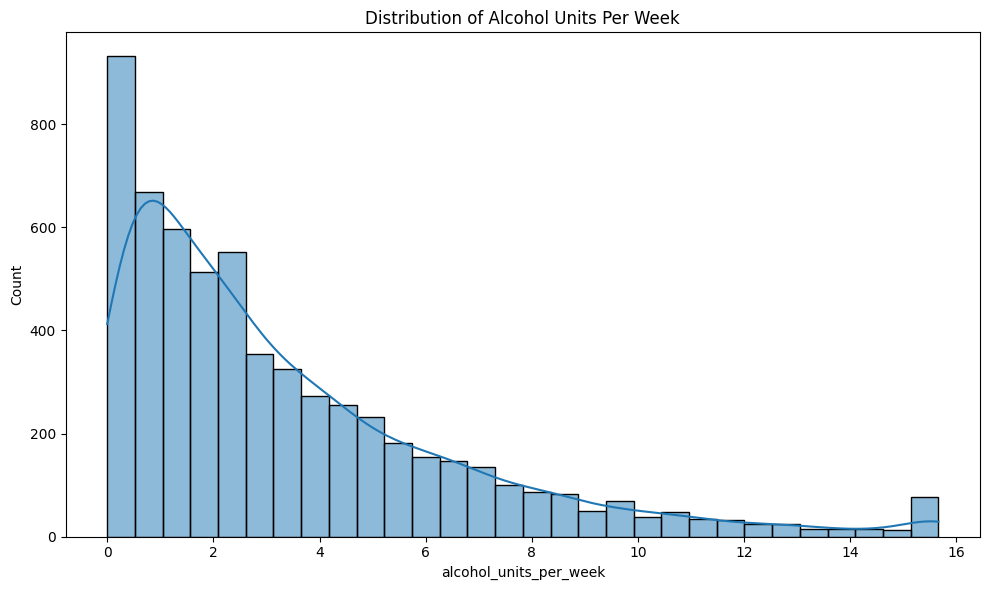

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_copy, x='alcohol_units_per_week', bins=30, kde=True)
plt.title('Distribution of Alcohol Units Per Week')
plt.tight_layout()
plt.savefig('../reports/figures/alcohol_units_distribution.png')
plt.show()

# alcohol units per week col
- based on the visuazliztion the histograms shows that it is positively skewed 

**strategy** 
- quantile, iqr, transform